In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [42]:
data_dir = "../data/ROUND1/"
def prices_day(n): return f"prices_round_1_day_{n}.csv"
def trades_day(n): return f"trades_round_0_day_{n}.csv"


In [43]:
n = "-2"
price_df = pd.read_csv(data_dir + prices_day(n), delimiter=";")
price_df['product'].unique()

<ArrowStringArray>
['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Length: 2, dtype: str

In [44]:
def plot_product_analysis(df, product_name, window=20, detrend=True, remove_zeros=True, use_ma_detrend=True):
    # 1. Filter Data
    query = df["product"] == product_name
    if remove_zeros:
        query &= df['mid_price'] > 0
    
    y = df[query]['mid_price'].values
    x = np.arange(len(y))
    
    if len(y) < window:
        print(f"Not enough data for {product_name}")
        return

    # 2. Calculate GLOBAL Trend (Only for the Title/Label)
    # This is a "future leak" if used for trading, but fine for a post-hoc title.
    slope, intercept = np.polyfit(x, y, 1)

    # 3. Calculate Trailing Moving Average (LEAK-FREE)
    ma_series = pd.Series(y).rolling(window=window)
    ma = ma_series.mean()

    # 4. Process Detrending
    label_suffix = "Original"
    plot_data = y
    
    if detrend:
        if use_ma_detrend:
            # LEAK-FREE: Subtracting only past/present info
            plot_data = y - ma.values
            label_suffix = "MA-Detrended (Trailing)"
        else:
            # LEAK: signal.detrend uses the entire series (Global)
            plot_data = signal.detrend(y) 
            label_suffix = "Linear-Detrended (Global)"

    # 5. Stats - Handling NaNs from the trailing window
    valid_mask = ~np.isnan(plot_data)
    clean_data = plot_data[valid_mask]
    
    # Check if we have data left after windowing
    if len(clean_data) == 0:
        return None

    pct_above = (np.sum(clean_data > 0) / len(clean_data)) * 100
    pct_below = (np.sum(clean_data < 0) / len(clean_data)) * 100

    # 6. Plotting
    plt.figure(figsize=(12, 6))
    
    # Plot main series (using x[valid_mask] to align if needed, but plotting all is fine for visual)
    plt.plot(plot_data, label=f"{label_suffix} Price", alpha=0.7, color='steelblue' if not detrend else 'gray')
    
    if detrend:
        plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        plt.fill_between(x, plot_data, 0, where=(plot_data > 0), color='green', alpha=0.15)
        plt.fill_between(x, plot_data, 0, where=(plot_data < 0), color='red', alpha=0.15)
        plt.ylabel("Deviation from Trend")
    else:
        plt.plot(ma.values, label=f"{window}-Period MA", color='darkorange', linewidth=2)
        plt.ylabel("Price")

    plt.title(f"{product_name} ({label_suffix})\n"
              f"Linear Trend: y = {slope:.4f}x + {intercept:.2f} | Above: {pct_above:.1f}% Below: {pct_below:.1f}%")
    
    plt.xlabel("Time (Observations)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.show()

    return {"slope": slope, "intercept": intercept, "pct_above": pct_above, "pct_below": pct_below}

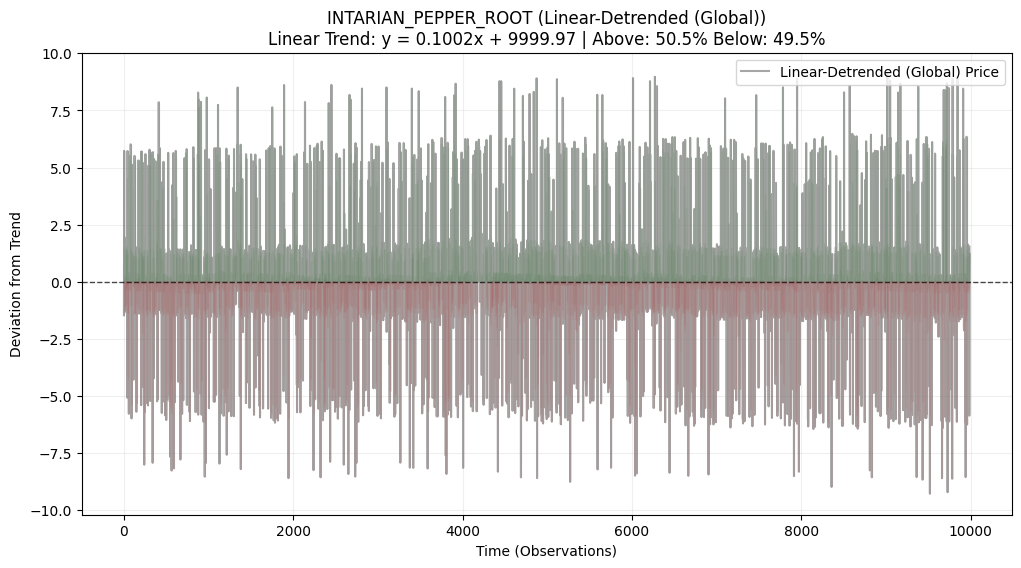

{'slope': np.float64(0.1001692005234352),
 'intercept': np.float64(9999.968977253939),
 'pct_above': np.float64(50.510817307692314),
 'pct_below': np.float64(49.48918269230769)}

In [45]:
prod_name = "INTARIAN_PEPPER_ROOT"

plot_product_analysis(price_df, prod_name, use_ma_detrend=False, detrend=True, window=200)

In [46]:
price_df[price_df['product'] == prod_name]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0
7,-2,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0
9,-2,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,-2,999500,INTARIAN_PEPPER_ROOT,10991.0,20.0,NaN,NaN,NaN,NaN,11008.0,20.0,NaN,NaN,NaN,NaN,10999.5,0.0
19993,-2,999600,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11006.0,9.0,NaN,NaN,NaN,NaN,11000.0,0.0
19994,-2,999700,INTARIAN_PEPPER_ROOT,10994.0,10.0,10991.0,18.0,NaN,NaN,11008.0,18.0,NaN,NaN,NaN,NaN,11001.0,0.0
19996,-2,999800,INTARIAN_PEPPER_ROOT,10994.0,11.0,10991.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10994.0,0.0


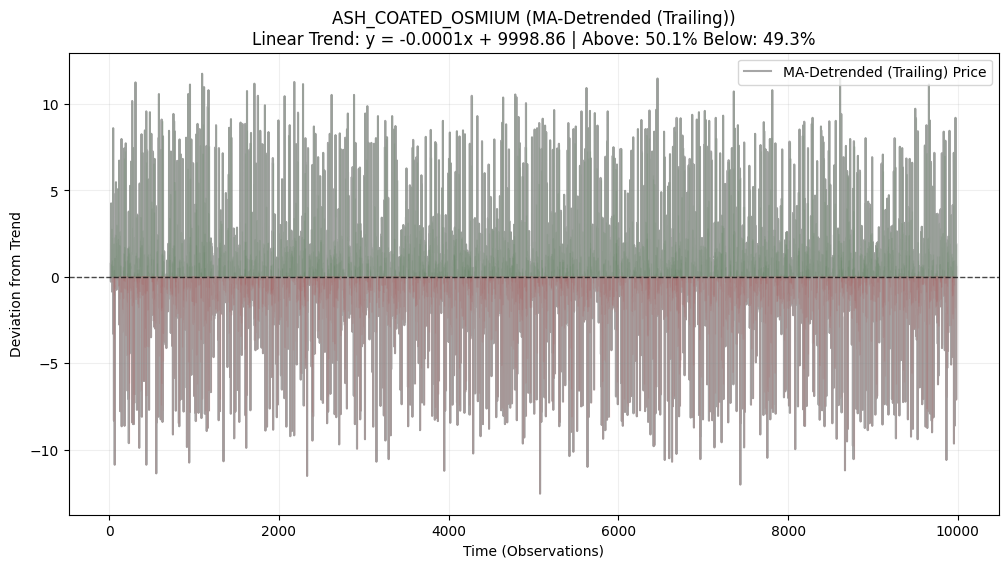

{'slope': np.float64(-0.00013912477971729),
 'intercept': np.float64(9998.864208043673),
 'pct_above': np.float64(50.05520425574627),
 'pct_below': np.float64(49.27230753789019)}

In [47]:
prod_name = "ASH_COATED_OSMIUM"
plot_product_analysis(price_df, prod_name, use_ma_detrend=True, detrend=True)

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# --- Robust Statistical Helpers ---

def calc_half_life(arr):
    if len(arr) < 10 or np.std(arr) < 1e-9: 
        return np.nan
    # Normalize to prevent polyfit overflow with high price values
    norm_arr = (arr - np.mean(arr)) / np.std(arr)
    y = np.diff(norm_arr)
    x = norm_arr[:-1]
    slope, _ = np.polyfit(x, y, 1)
    # Return capped value if trending, else calculate HL
    return -np.log(2) / slope if slope < 0 else len(arr)

def calc_hurst(arr):
    if len(arr) < 50 or np.std(arr) < 1e-9: 
        return 0.5
    lags = range(2, 20)
    tau = [np.std(arr[lag:] - arr[:-lag]) + 1e-10 for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

def calc_adf_pval(arr):
    if len(arr) < 50 or np.std(arr) < 1e-9:
        return 1.0
    try:
        # maxlag=1 for speed in rolling windows
        return adfuller(arr, maxlag=1, autolag=None)[1]
    except:
        return 1.0

# --- Main Analysis Function ---

def plot_advanced_quant_analysis(df, product_name, window=200):
    # 1. Immediate Filter: Remove rows where mid_price is 0 or NaN
    # We also filter by product name here
    clean_df = df[(df["product"] == product_name) & (df["mid_price"] > 0)].copy()
    clean_df = clean_df.reset_index(drop=True)
    
    if len(clean_df) < window:
        print(f"Not enough non-zero data for {product_name}")
        return

    prices = clean_df['mid_price']

    # 2. Compute Rolling Metrics
    print(f"Calculating metrics for {product_name} ({len(clean_df)} samples)...")
    
    hl = prices.rolling(window=window).apply(calc_half_life, raw=True)
    hurst = prices.rolling(window=window).apply(calc_hurst, raw=True)
    adf_p = prices.rolling(window=window).apply(calc_adf_pval, raw=True)

    # 3. Plotting
    fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)
    t = np.arange(len(clean_df))

    # Panel 1: Cleaned Price
    axes[0].plot(t, prices, color='steelblue', label='Mid Price (Zeros Removed)')
    axes[0].set_title(f"{product_name} Price Dynamics")
    axes[0].set_ylabel("Price")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Panel 2: Half-Life
    axes[1].plot(t, hl.clip(upper=window*2), color='purple', label='Half-Life')
    # Filter NaNs just for the median line calculation
    valid_hl = hl.dropna()
    if not valid_hl.empty:
        axes[1].axhline(valid_hl.median(), color='black', linestyle='--', label=f'Median: {valid_hl.median():.1f}')
    axes[1].set_title("Mean-Reversion Half-Life (Periods)")
    axes[1].set_ylabel("Steps to Revert")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Hurst Exponent
    axes[2].plot(t, hurst, color='teal', label='Hurst Exponent')
    axes[2].axhline(0.5, color='red', linestyle='-', alpha=0.5, label='Random Walk (0.5)')
    axes[2].fill_between(t, hurst, 0.5, where=(hurst < 0.5), color='green', alpha=0.2, label='Mean Reverting')
    axes[2].set_title("Hurst Exponent (Market Memory)")
    axes[2].set_ylabel("H")
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    # Panel 4: ADF Stationarity
    axes[3].plot(t, adf_p, color='maroon', label='ADF p-value')
    axes[3].axhline(0.05, color='red', linestyle='--', label='95% Confidence (0.05)')
    axes[3].fill_between(t, adf_p, 0.05, where=(adf_p < 0.05), color='green', alpha=0.2, label='Stationary')
    axes[3].set_title("ADF Test (Stationarity Check)")
    axes[3].set_xlabel("Time Index (Non-Zero Ticks)")
    axes[3].set_ylabel("p-value")
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'hl': hl, 'hurst': hurst, 'adf_p': adf_p})

# Usage
# results = plot_advanced_quant_analysis(price_df, "ASH_COATED_OSMIUM")

Calculating metrics for ASH_COATED_OSMIUM (9982 samples)...


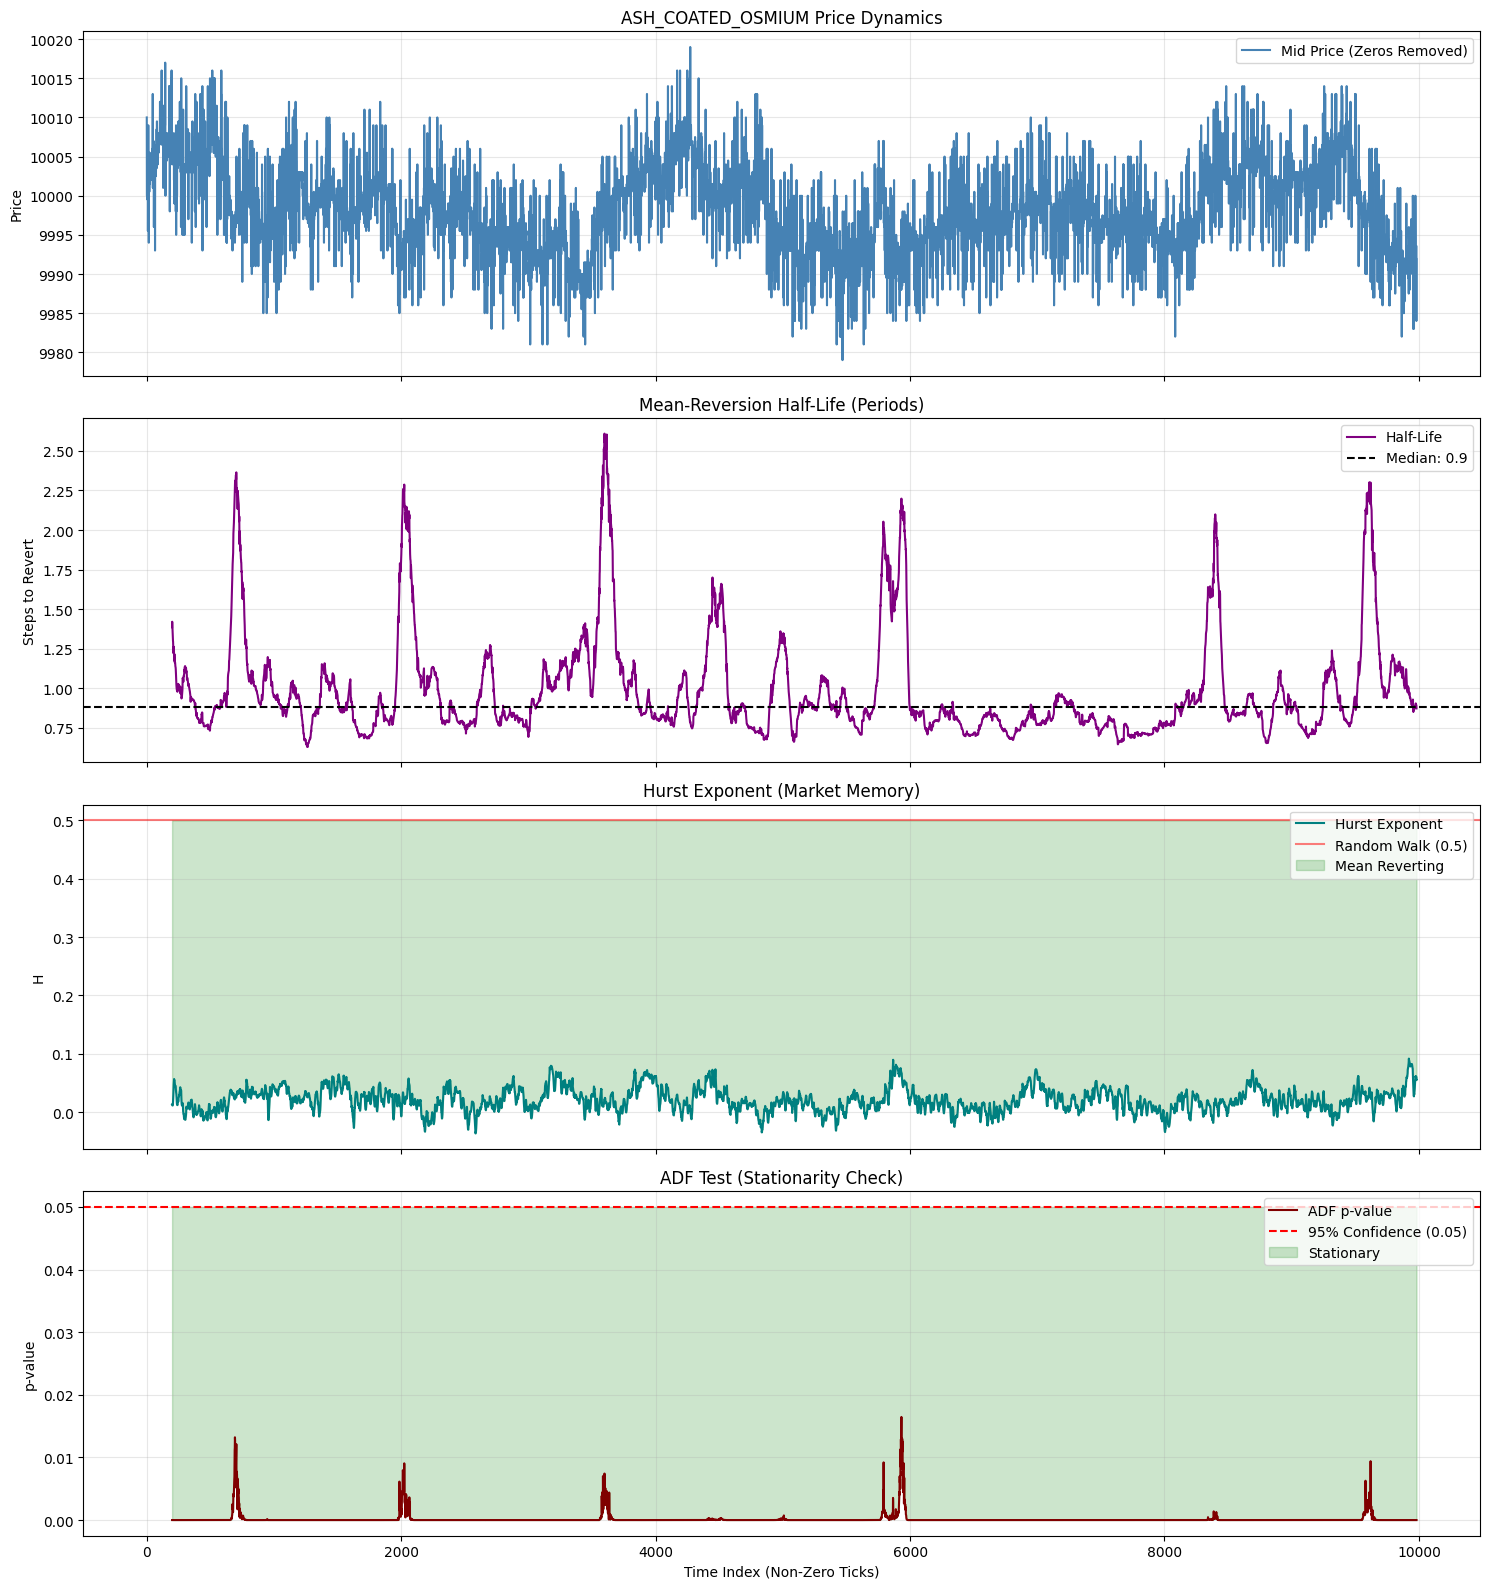

,hl,hurst,adf_p
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
9977,0.897338,0.059522,2.628247e-11
9978,0.895610,0.059877,2.317239e-11
9979,0.893386,0.060972,2.439683e-11
9980,0.891839,0.055085,7.590205e-11


In [54]:
plot_advanced_quant_analysis(price_df, prod_name, window=200)